# GRSS Example
This notebook is intended to serve as an example on how to perform orbit determination with the Gauss Radau Solar System propagator package. https://rahil-makadia.github.io/grss/


In [1]:
# import GRSS
from grss import fit

Updating observatory codes from the MPC...
The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


/home/terra/miniforge3/envs/ae498/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import other numpy and time converter via astropy
import numpy as np
np.set_printoptions(precision=10, linewidth=np.inf)

from astropy.time import Time

In [3]:
# import matplotlib based plotting routines

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'STIXGeneral'
# matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

font = {'family' : 'serif',
         'size'   : 11,
         'serif':  'cmr10'
         }

matplotlib.rc('font', **font)
matplotlib.rcParams["axes.formatter.use_mathtext"] = True


In [4]:
# Perihelion time (MJD TDB) from Find_Orb hw3 output
# Tp = Epoch - M/n = 60522.0 - 37.8569629267656 / 0.4650615212718
60522.0 - 37.8569629267656 / 0.4650615212718

60440.59794630345

## Initial conditions for the target asteroid
If the asteroid is named a query from the NASA Small Body Database can provide initial orbits and covariances. Alternatively, one can also add a user provided Initial Orbit with Covariances as well as user determined acceleration values a1, a2 and a3, as well as scaling paratmeters for a Marsden-like non-gravitational force model.

In [5]:
# NASA Small Body Database designation of Solar System Object
body_id = 'SYNTH'
try:
    init_sol, init_cov, nongrav_info = fit.get_sbdb_info(body_id)
except:
    print(f"Failed to get SBDB info for {body_id}. Reverting to user supplied initial orbit).")
    # Orbital elements from Find_Orb hw3 output (PDC25 scenario, Epoch 2024 Jul 31.0 TT)
    # 98 observations 2024 Jun 5 - Jul 31, mean residual 0".02
    init_sol = {'t': 60522.0,                              # MJD TDB (JD 2460522.5)
                'e': 0.3906482439600,                      # eccentricity
                'q': 1.0053806237781,                      # perihelion distance [AU]
                'tp': 60440.59794630,                      # perihelion time [MJD TDB] (JD 2460441.09794630)
                'om': 214.4238628718134 / 180 * np.pi,    # longitude of ascending node [rad]
                'w': 359.9636678818429 / 180 * np.pi,     # argument of perihelion [rad]
                'i': 10.6887240189021 / 180 * np.pi}      # inclination [rad]

    # Diagonal covariance from Find_Orb hw3 sigma values
    # Order matches init_sol: e, q [AU], tp [days MJD], om [rad], w [rad], i [rad]
    _sig_e  = 1.14e-5                        # dimensionless
    _sig_q  = 1.08e-6                        # AU
    _sig_tp = 3.66e-4                        # days
    _sig_om = 3.3e-4 * np.pi / 180          # rad
    _sig_w  = 4.7e-4 * np.pi / 180          # rad
    _sig_i  = 1.5e-4 * np.pi / 180          # rad
    init_cov = np.diag([_sig_e**2, _sig_q**2, _sig_tp**2, _sig_om**2, _sig_w**2, _sig_i**2])
 
    nongrav_info = {
        'a1': 0.0,
        'a2': 0.0,
        'a3': 0.0,
        'alpha': 1.0,
        'k': 0.0,
        'm': 2.0,
        'n': 0.0,
        'r0_au': 1.0,
        'radius': 0.0,
    }
# specify JPL DExxx kernel used for planetary ephemerides
de_kernel = 440

Failed to get SBDB info for SYNTH. Reverting to user supplied initial orbit).


In [6]:
214.4238628718134 / 180 * np.pi

3.742402401957968

In [7]:
359.9636678818429 / 180 * np.pi

6.282551192093521

In [8]:
10.6887240189021 / 180 * np.pi

0.18655342696684224

In [9]:
# activate non-gravitaional forces

add_a1 = False
add_a2 = False
add_a3 = False
ng_guess = 1e-13
if add_a1:
    # add a1 to init_sol
    init_sol['a1'] = ng_guess
    # add row and column for a1 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a2:
    # add a2 to init_sol
    init_sol['a2'] = ng_guess
    # add row and column for a2 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a3:
    # add a3 to init_sol
    init_sol['a3'] = ng_guess
    # add row and column for a3 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)

## Determine parameters for the Least Squares filtering of observations

In [10]:
# add observations by the ESA's Gaia satellite (requires special treatment)
add_gaia_obs = False

# restrict timespan observations are considered for
t_min_tdb = None
t_max_tdb = None
# use lower resolution asteroid catalog debiasing scheme (JPL default, see Eggl+ 2020)
debias_lowres = False
# deweight outlier observations rather than eliminate them
deweight = True
eliminate = False
# limit the number of observations per night used in the fit. Avoids biases toward single nights that have many observations
num_obs_per_night = 4
# verbose filtering feedback
verbose = True


## Read in optical observations from File

In [11]:
# add additional file containing observations in ADES format
optical_obs_file = "2024PDC25.xml"

# # get optical observations from file
obs_df = fit.get_optical_obs(body_id, optical_obs_file, t_min_tdb, t_max_tdb, debias_lowres, deweight, eliminate, num_obs_per_night, verbose)


Read in 98 observations from the file.
	Filtered to 98 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: UNK
	No debiasing needed for 0 observations.
	Debiased 0 observations.
	No bias information for 98 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 0 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 98 observations.


In [12]:
obs_df

,permID,provID,mode,stn,prog,obsTime,rmsTime,ra,dec,rmsRA,...,biasDec,biasTime,resDelay,resDoppler,sigDelay,sigDoppler,obsTimeMJD,obsTimeMJDTDB,cosDec,resChi
0,NaN,NaN,CCD,500,NaN,2024-07-31T02:24:00.00Z,NaN,252.359367,8.056822,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.1,60522.100801,0.990130,NaN
1,NaN,NaN,CCD,500,NaN,2024-07-31T00:00:00.00Z,NaN,252.285371,8.098561,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.0,60522.000801,0.990027,NaN
2,NaN,NaN,CCD,500,NaN,2024-07-28T02:24:00.00Z,NaN,250.091267,9.330564,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.1,60519.100801,0.986769,NaN
3,NaN,NaN,CCD,500,NaN,2024-07-28T00:00:00.00Z,NaN,250.013854,9.373778,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.0,60519.000801,0.986647,NaN
4,NaN,NaN,CCD,500,NaN,2024-07-25T02:24:00.00Z,NaN,247.712908,10.647547,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60516.1,60516.100801,0.982782,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,NaN,NaN,CCD,500,NaN,2024-06-07T00:00:00.00Z,NaN,179.611383,27.683458,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60468.0,60468.000801,0.885528,NaN
94,NaN,NaN,CCD,500,NaN,2024-06-06T02:24:00.00Z,NaN,177.806604,27.583594,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60467.1,60467.100801,0.886336,NaN
95,NaN,NaN,CCD,500,NaN,2024-06-06T00:00:00.00Z,NaN,177.606354,27.570900,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60467.0,60467.000801,0.886439,NaN
96,NaN,NaN,CCD,500,NaN,2024-06-05T02:24:00.00Z,NaN,175.807604,27.442472,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60466.1,60466.100801,0.887474,NaN


## Construct the fitting instance

In [13]:
n_iter_max = 20
fit_sim = fit.FitSimulation(init_sol, obs_df, init_cov, n_iter_max=n_iter_max, de_kernel=de_kernel, nongrav_info=nongrav_info)
fit_sim.reject_outliers = True
fit_sim.analytic_partials = True
fit_sim.reject_criteria = [2.0, 1.8]

## Perform the fit

In [14]:

fit_sim.filter_lsq()

Iteration		Unweighted RMS		Weighted RMS 		Chi-squared		Reduced Chi-squared
1			 0.533			 0.108			 2.271			 0.012
2			 0.004			 0.001			 0.000			 0.000
Converged without rejecting outliers. Starting outlier rejection now...
3			 0.004			 0.001			 0.000			 0.000
Converged after rejecting outliers. Rejected 0 out of 98 optical observations.


## Plot the results

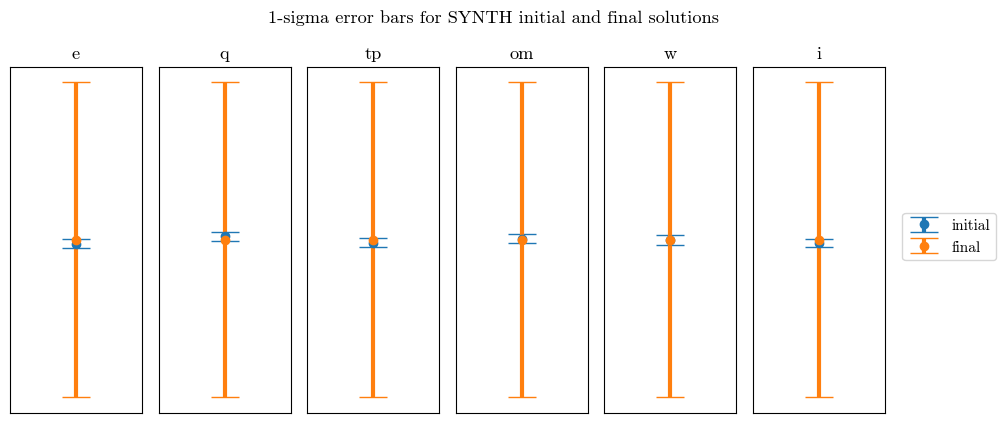

In [15]:
# plot error bars for initial and final solution
n_sig = 1
labels = ['initial', 'final']
keys = list(fit_sim.x_init.keys())
init = list(fit_sim.x_init.values())
init_sig = np.diag(fit_sim.covariance_init)**0.5
nom = list(fit_sim.x_nom.values())
nom_sig = np.diag(fit_sim.covariance)**0.5
plt.figure(figsize=(10, 4), dpi=100)
for elem_idx in range(len(keys)):
    plt.subplot(1, len(keys), elem_idx+1)
    plt.errorbar(0, init[elem_idx], yerr=init_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[0])
    plt.errorbar(0, nom[elem_idx], yerr=nom_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[1])
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    plt.title(keys[elem_idx])
plt.legend(ncol=1, bbox_to_anchor=(1.9,0.6))
plt.tight_layout()
plt.suptitle(f'{n_sig}-sigma error bars for {body_id} initial and final solutions', y=1.05)
plt.show()

In [16]:
fit_sim.print_summary()

Summary of the orbit fit calculations after postfit pass:
RMS unweighted: 0.0036223967471722897
RMS weighted: 0.0007318095201990947
chi-squared: 0.00010496685407538971
reduced chi-squared: 5.524571267125775e-07
square root of reduced chi-squared: 0.0007432745971123845
--------------------------------------------------------------
Solution Time: MJD 60522.000 TDB = 2024-07-31 00:00:00.000 TDB
Solution Observation Arc: 56.10 days (0.15 years)
--------------------------------------------------------------
Fitted Variable		Initial Value			Uncertainty			Fitted Value			Uncertainty			Change				Change (sigma)
e			3.90648243960e-01		1.14000000000e-05		3.90657610603e-01		3.99772894572e-04		+9.36664282070e-06		+0.023
q			1.00538062378e+00		1.08000000000e-06		1.00537976723e+00		3.71592308823e-05		-8.56545782524e-07		-0.023
tp			6.04405979463e+04		3.66000000000e-04		6.04405981859e+04		1.26725880708e-02		+2.39566092205e-04		+0.019
om			2.14423862872e+02		3.30000000000e-04		2.14423796392e+02		1.17235

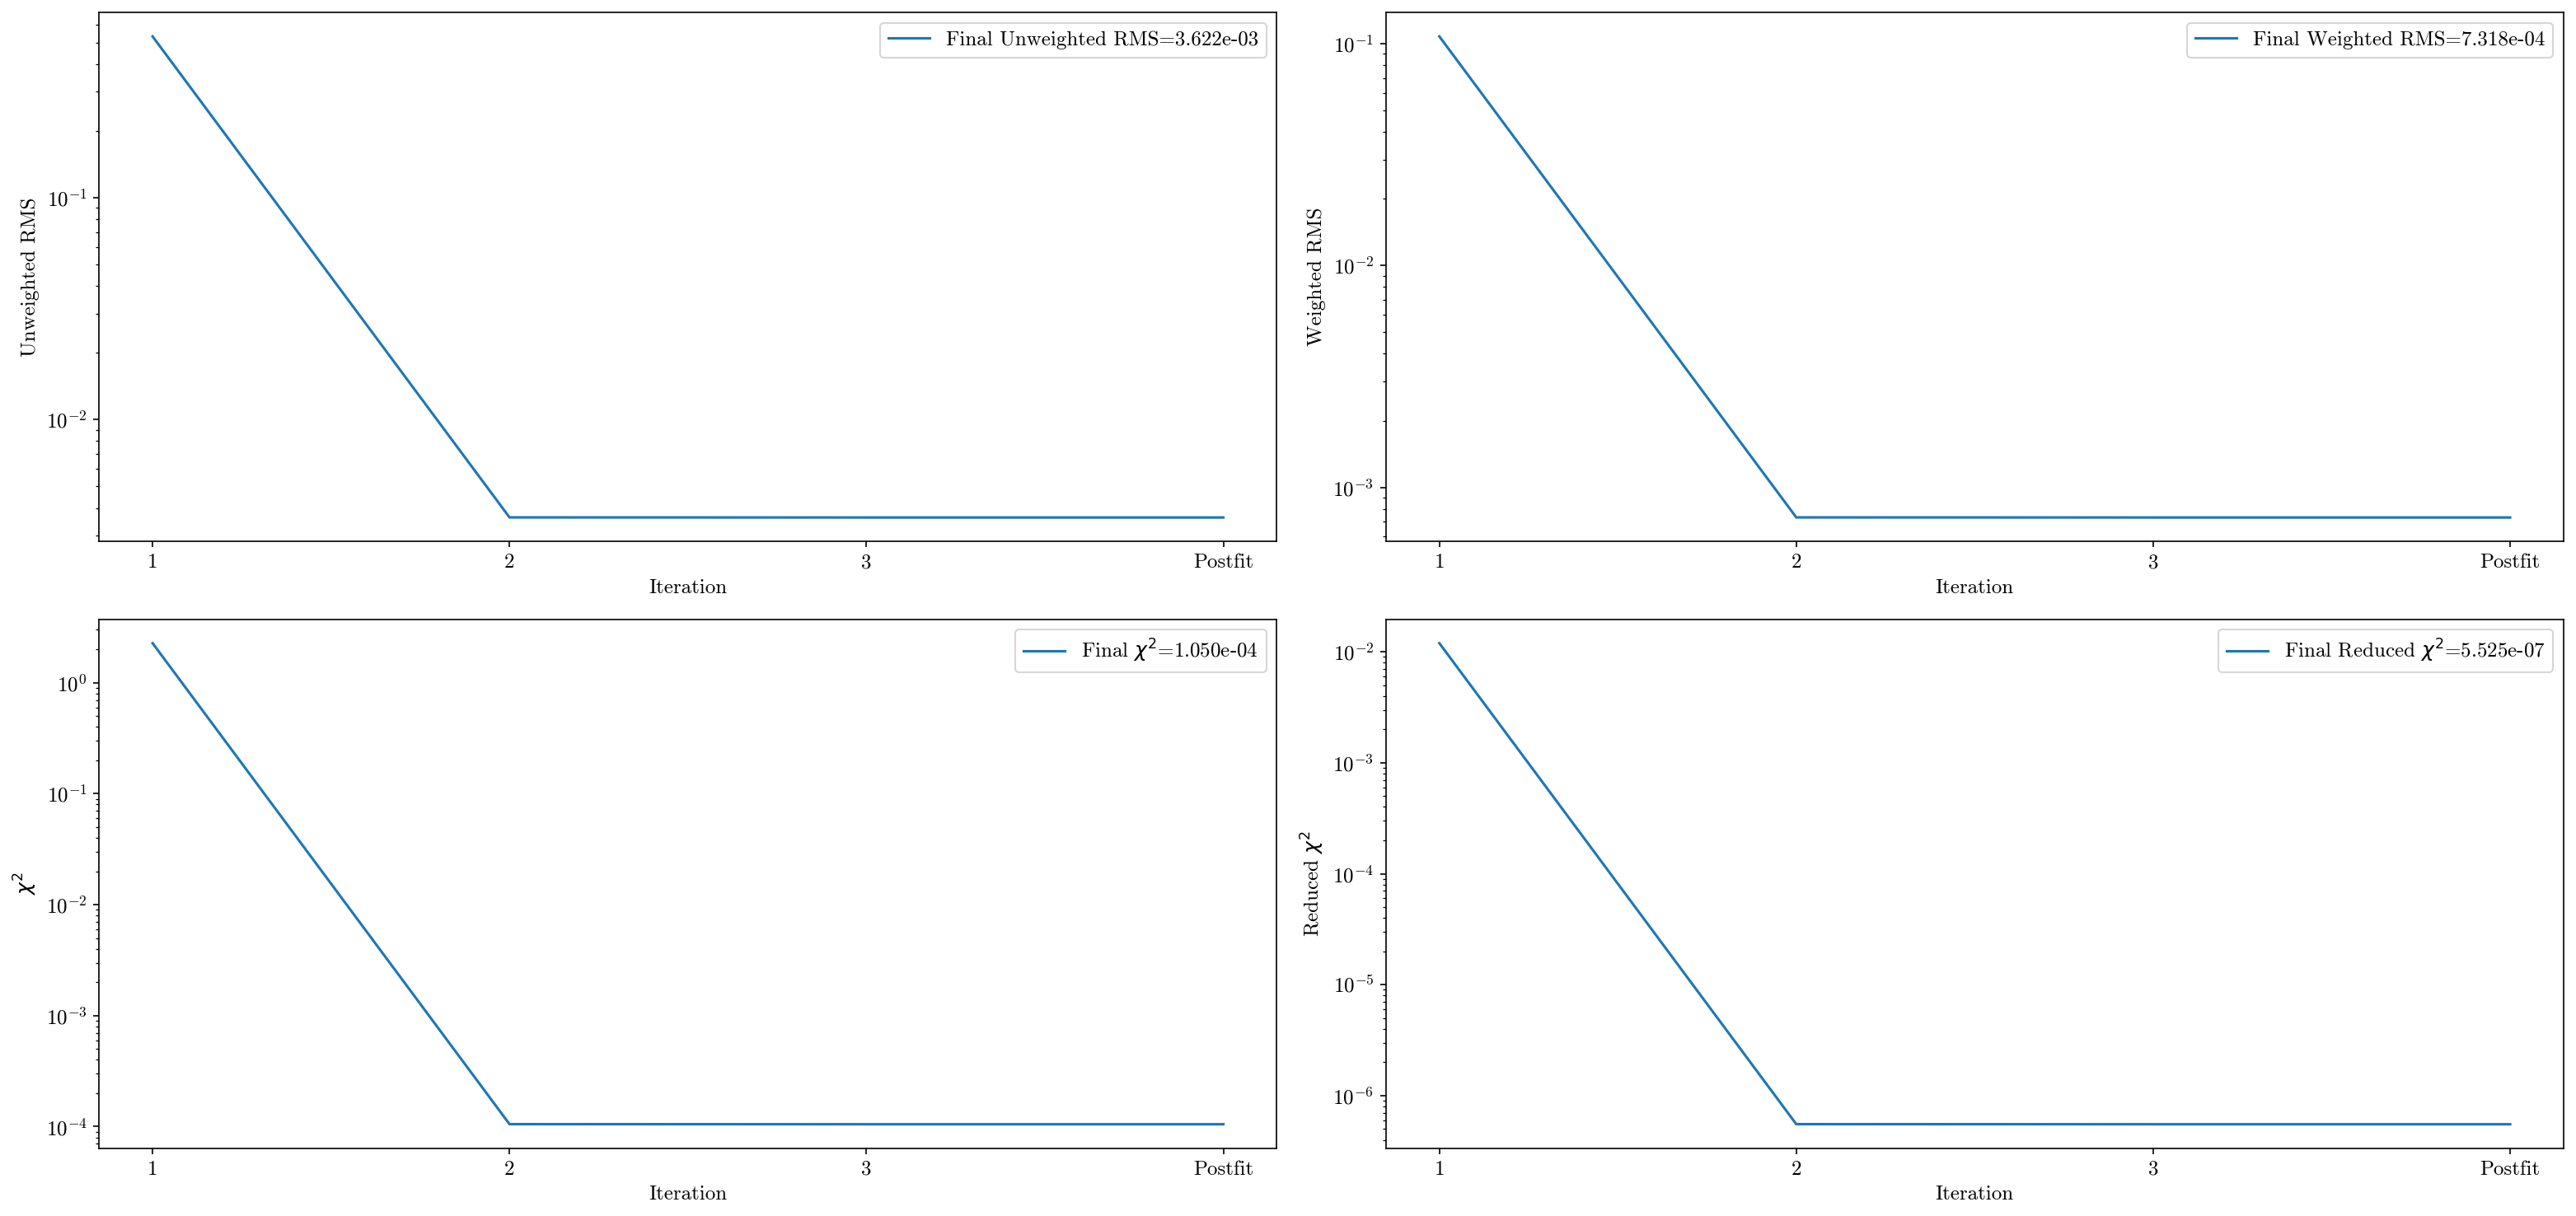

In [17]:
fit_sim.plot_summary(auto_close=True)

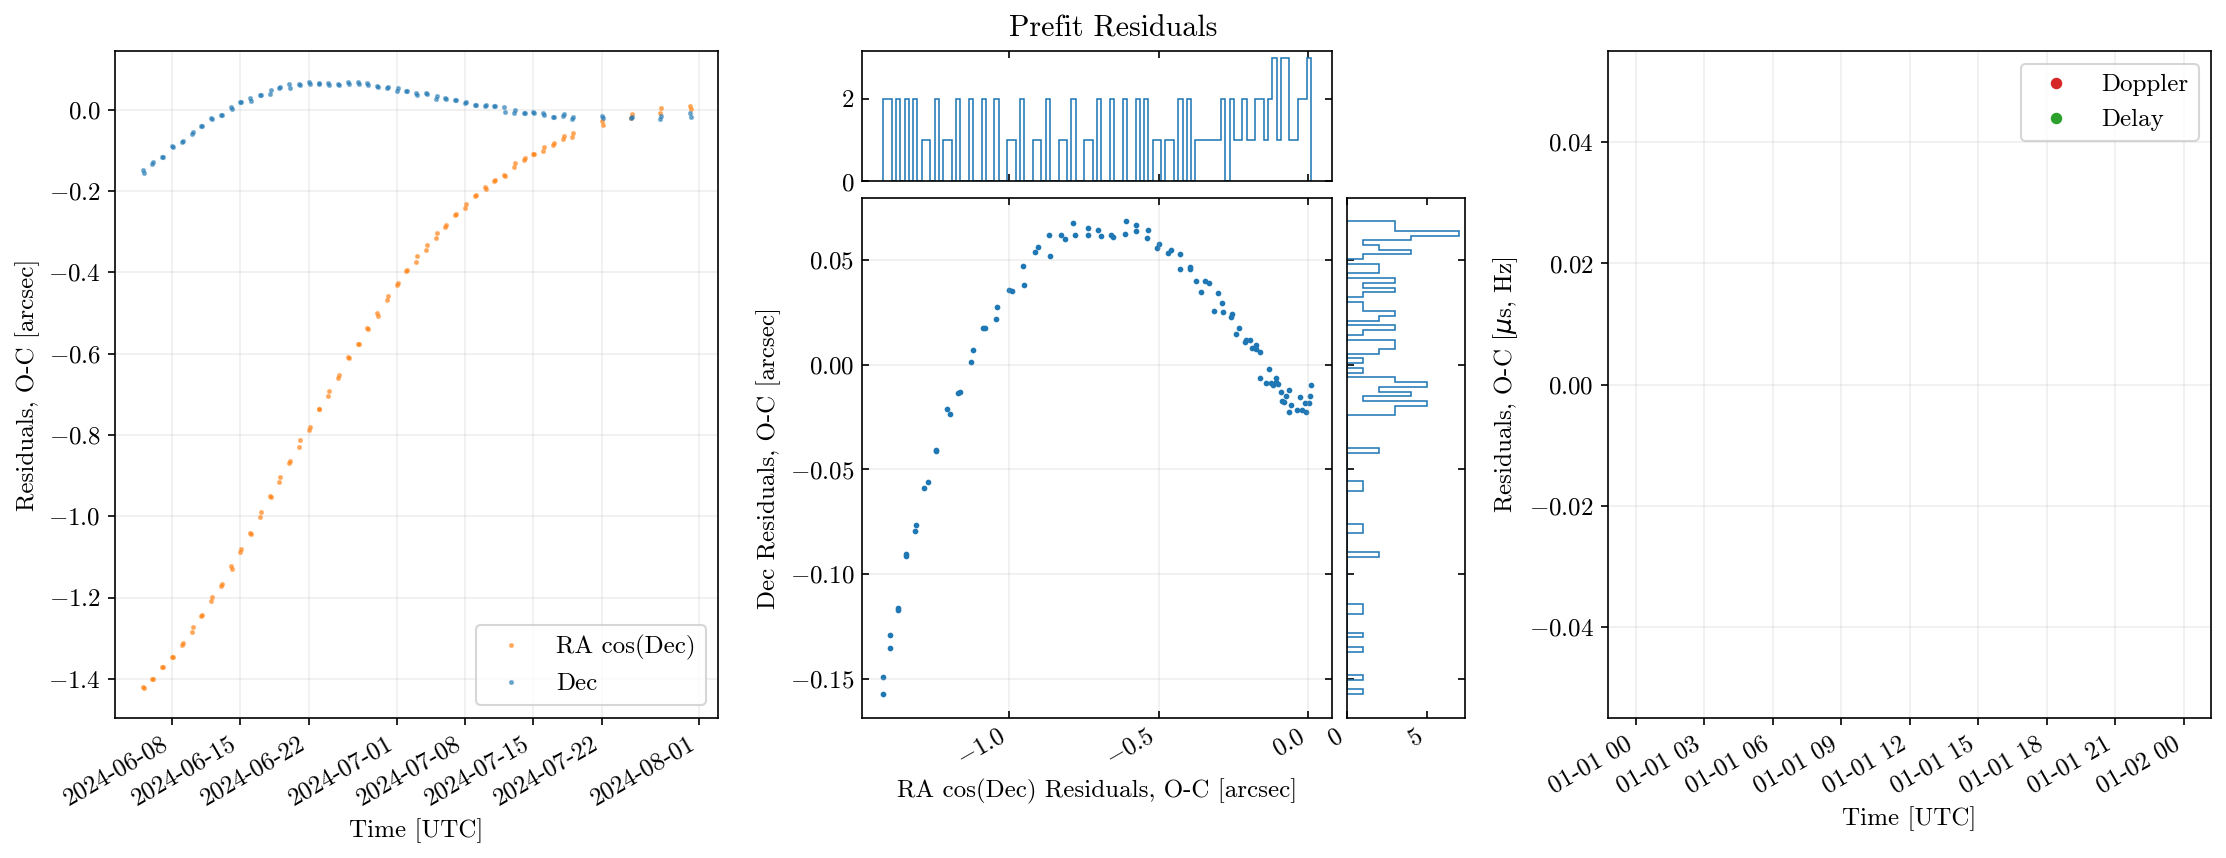

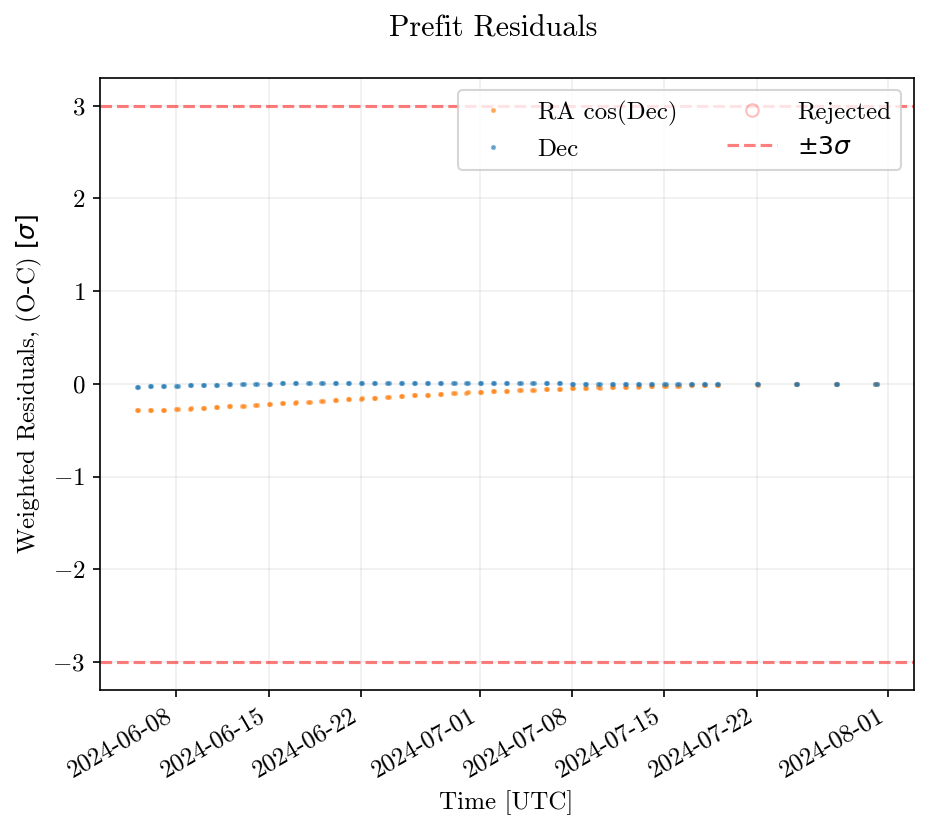

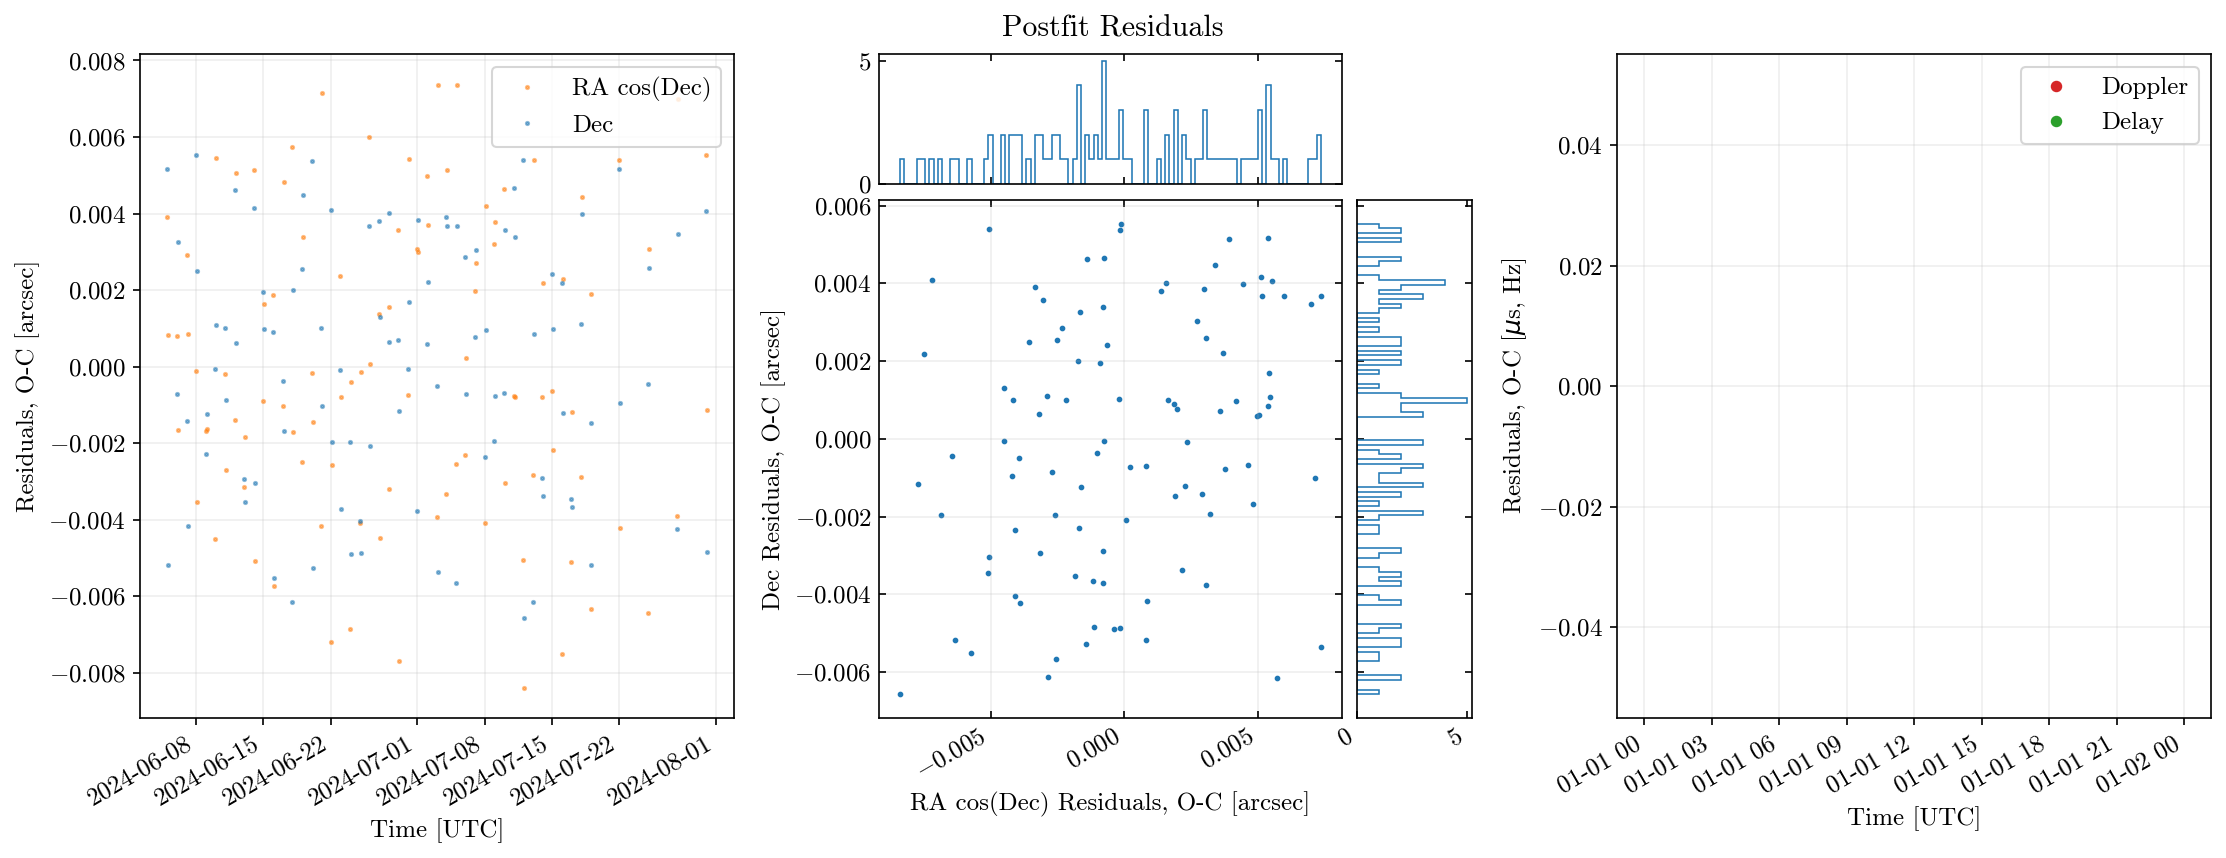

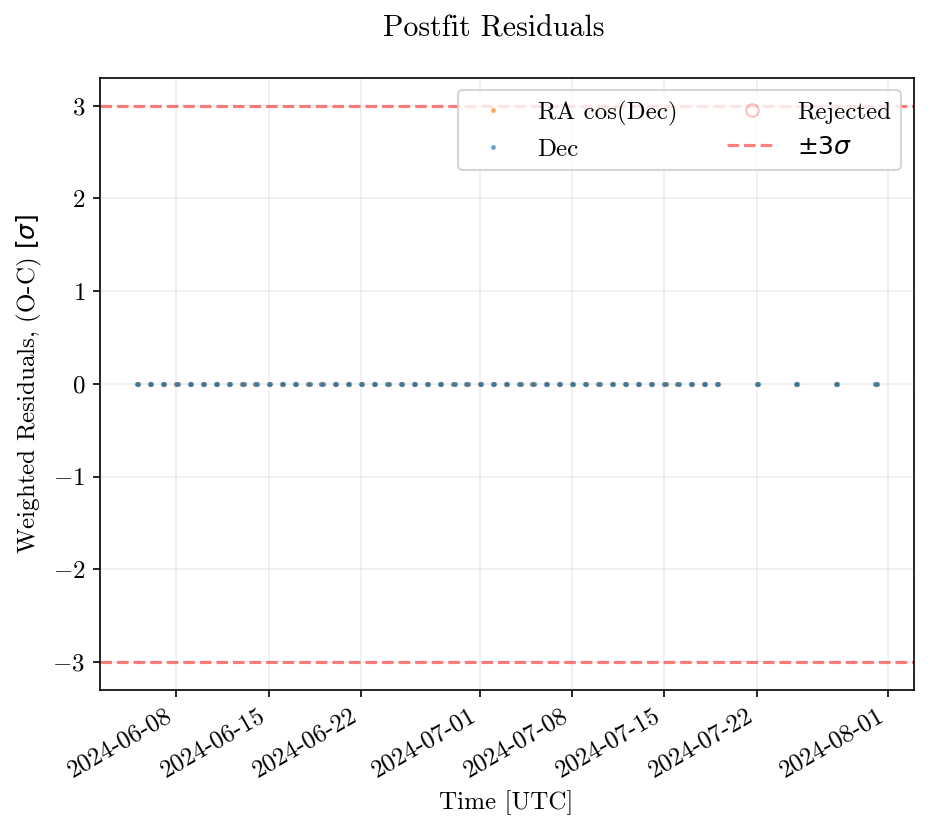

In [18]:
fit_sim.iters[1].plot_iteration_summary(title='Prefit Residuals', auto_close=True)
fit_sim.iters[-1].plot_iteration_summary(title='Postfit Residuals', auto_close=True)

In [19]:
mean_0 = np.array(list(init_sol.values())[1:])
cov_0 = init_cov
mean_f = np.array(list(fit_sim.x_nom.values()))
cov_f = fit_sim.covariance

if np.all(init_cov != 0):
    maha_dist_f, maha_dist_0, bhattacharya, bhatt_coeff = fit.get_similarity_stats(mean_0, cov_0, mean_f, cov_f)
    print(f'Mahalonobis distance between JPL and GRSS solution: {maha_dist_f:0.2f}')
    print(f'Mahalonobis distance between GRSS and JPL solution: {maha_dist_0:0.2f}')
    print(f'Bhattacharya distance between JPL and GRSS solution: {bhattacharya:0.4f}')
    print(f'Bhattacharya coefficient between JPL and GRSS solution: {bhatt_coeff:0.4f}')

In [20]:
print(mean_f)

[3.9065761060e-01 1.0053797672e+00 6.0440598186e+04 3.7424012417e+00 6.2825515294e+00 1.8655532713e-01]


In [21]:
print(cov_f)

[[ 1.5981836723e-07  1.4670107127e-08  5.0317158781e-06 -8.1373480143e-08  1.1165780037e-07  3.7240152906e-08]
 [ 1.4670107127e-08  1.3808084398e-09  4.7024238146e-07 -7.5577845349e-09  1.0516144991e-08  3.3962677941e-09]
 [ 5.0317158781e-06  4.7024238146e-07  1.6059448841e-04 -2.5840923539e-06  3.5838436280e-06  1.1663559173e-06]
 [-8.1373480143e-08 -7.5577845349e-09 -2.5840923539e-06  4.1866847179e-08 -5.7750180325e-08 -1.8874634348e-08]
 [ 1.1165780037e-07  1.0516144991e-08  3.5838436280e-06 -5.7750180325e-08  8.0357912242e-08  2.5801989308e-08]
 [ 3.7240152906e-08  3.3962677941e-09  1.1663559173e-06 -1.8874634348e-08  2.5801989308e-08  8.7006859352e-09]]


## Unscented Transform Orbit & Covariance Propagation to April 24, 2041



In [ ]:
from grss import prop
from grss.utils import default_kernel_path
from astropy.time import Time
import numpy as np

# Constants

AU_km       = 149597870.7        # km per AU
R_earth_km  = 6371.0             # Earth equatorial radius [km]
R_earth_AU  = R_earth_km / AU_km # Earth radius [AU]  ≈ 4.26e-5


t_impact_iso = '2041-04-24T00:00:00'
t_impact_mjd = Time(t_impact_iso, scale='tdb').mjd
t_epoch_mjd  = fit_sim.t_sol              # 2024-Jul-31 (MJD TDB)
t_final_mjd  = t_impact_mjd + 60.0       # 60-day buffer past expected encounter

prop_days  = t_final_mjd - t_epoch_mjd
prop_years = prop_days / 365.25

print(f"Orbit epoch : MJD {t_epoch_mjd:.3f}  "
      f"({Time(t_epoch_mjd, format='mjd', scale='tdb').iso[:10]})")
print(f"Impact date : MJD {t_impact_mjd:.3f}  ({t_impact_iso[:10]})")
print(f"Propagation : {prop_days:.1f} days  ({prop_years:.4f} years)")
print(f"Earth radius: {R_earth_AU:.4e} AU  ({R_earth_km:.0f} km)")


# Best-fit solution and covariance from GRSS orbit determination
# Keys: e, q [AU], tp [MJD TDB], om [rad], w [rad], i [rad]

x_nom_6 = {k: v for k, v in fit_sim.x_nom.items() if k != 't'}
cov_f   = fit_sim.covariance   # 6×6 in same element order

print(f"\nBest-fit elements (post-fit):")
for k, v in x_nom_6.items():
    print(f"  {k:4s} = {v:.12g}")
print(f"\n1-σ uncertainties (√diag(P)):")
for k, s in zip(x_nom_6.keys(), np.sqrt(np.diag(cov_f))):
    print(f"  σ_{k:4s} = {s:.3e}")


# Generate Julier sigma points (κ = 0)  →  2n+1 = 13 points
# with κ = 0:
#   X₀  = x̄              (mean)
#   Xᵢ  = x̄ + (√(nP))ᵢ  (positive perturbations, i = 1,...,n)
#   Xᵢ₊ₙ= x̄ − (√(nP))ᵢ  (negative perturbations, i = n+1,...,2n)
# Weights:  W₀ = 0,   Wᵢ = 1/(2n) = 1/12

sigma_pts = prop.SigmaPoints(x_nom_6, cov_f, 'julier', kappa=0.0)
n_sp  = len(sigma_pts.sigma_points)      # 2n+1 = 13
n_dim = sigma_pts.sigma_points.shape[1]  # n = 6

print(f"\nSigma points generated: {n_sp}  (2n+1,  n = {n_dim})")
print(f"  W₀  = {sigma_pts.w_m[0]:.4f}  (central / mean point)")
print(f"  Wᵢ  = {sigma_pts.w_m[1]:.6f}  (each ±-perturbation, i = 1,...,{2*n_dim})")
print(f"  ΣWᵢ = {sigma_pts.w_m.sum():.6f}  (should equal 1)")

Orbit epoch : MJD 60522.000  (2024-07-31)
Impact date : MJD 66633.000  (2041-04-24)
Propagation : 6171.0 days  (16.8953 years)
Earth radius: 4.2588e-05 AU  (6371 km)

Best-fit elements (post-fit):
  e    = 0.390657610603
  q    = 1.00537976723
  tp   = 60440.5981859
  om   = 3.74240124166
  w    = 6.28255152938
  i    = 0.186555327132

1-σ uncertainties (√diag(P)):
  σ_e    = 3.998e-04
  σ_q    = 3.716e-05
  σ_tp   = 1.267e-02
  σ_om   = 2.046e-04
  σ_w    = 2.835e-04
  σ_i    = 9.328e-05

Sigma points generated: 13  (2n+1,  n = 6)
  W₀  = 0.0000  (central / mean point)
  Wᵢ  = 0.083333  (each ±-perturbation, i = 1,...,12)
  ΣWᵢ = 1.000000  (should equal 1)


In [46]:

# Propagate all 13 sigma points from 2024-Jul-31 → April 24, 2041
# using GRSS high-fidelity N-body integrator:
#   • Newtonian gravity: Sun, planets, Moon, 16 main-belt asteroids
#   • Einstein–Infeld–Hoffmann (EIH) relativistic corrections
#   • J₂ of Sun and Earth
#   • DE440 planetary ephemerides

# --- Non-gravitational parameters (PDC25 is synthetic: zero Yarkovsky) ---
ng_params = prop.NongravParameters()
ng_params.a1    = nongrav_info['a1'];    ng_params.a2    = nongrav_info['a2']
ng_params.a3    = nongrav_info['a3'];    ng_params.alpha = nongrav_info['alpha']
ng_params.k     = nongrav_info['k'];     ng_params.m     = nongrav_info['m']
ng_params.n     = nongrav_info['n'];     ng_params.r0_au = nongrav_info['r0_au']

# --- Create PropSimulation ---
prop_sim = prop.PropSimulation('pdc25_ut', t_epoch_mjd, de_kernel, default_kernel_path)

# --- Add all 13 IntegBodies (one per sigma point) ---
# Cometary state order: [e, q, tp, om, w, i]  (matches x_nom_6 key order)
for k in range(n_sp):
    sp_k = sigma_pts.sigma_points[k].tolist()
    body = prop.IntegBody(
        f'sp_{k}',      # unique name → used to identify caParams entries
        t_epoch_mjd,    # epoch [MJD TDB]
        0.0,            # mass [kg]   (test particle)
        0.0,            # radius [AU] (test particle: collision handled by Earth radius)
        sp_k,           # cometary state [e, q, tp, om, w, i]
        ng_params
    )
    body.caTol = 0.0    # flag close approaches within 0.1 AU (captures ~40 LD on each side)
    prop_sim.add_integ_body(body)

# --- Evaluate states at the precise impact date ---
prop_sim.set_integration_parameters(tf=t_final_mjd, tEval=[t_impact_mjd])

print(f"Integrating {n_sp} test particles over {prop_years:.2f} years ...")
prop_sim.integrate()
print("Integration complete.\n")

# ============================================================
# Collect Earth close approaches — one per sigma point
# ============================================================
ca_by_sp     = {}   # sp_idx → CloseApproachParameters (nearest to t_impact)
impact_by_sp = {}   # sp_idx → ImpactParameters (if impact occurred)

for ca in prop_sim.caParams:
    if ca.centralBody == 'Earth':
        sp_idx = int(ca.flybyBody.split('_')[1])
        # Keep the CA event closest in time to the predicted impact
        if sp_idx not in ca_by_sp or abs(ca.t - t_impact_mjd) < abs(ca_by_sp[sp_idx].t - t_impact_mjd):
            ca_by_sp[sp_idx] = ca

for imp in prop_sim.impactParams:
    if imp.centralBody == 'Earth':
        sp_idx = int(imp.flybyBody.split('_')[1])
        impact_by_sp[sp_idx] = imp

print(f"Earth close approaches detected: {len(ca_by_sp)} / {n_sp} sigma points")
print()
print(f"{'SP':>4}  {'Distance (km)':>16}  {'Distance (R⊕)':>14}  {'Time (UTC)':>22}  {'Impact?':>7}")
print("-" * 72)
for k in range(n_sp):
    if k in impact_by_sp:
        imp = impact_by_sp[k]
        d_km = imp.dist * AU_km
        t_str = Time(imp.t, format='mjd', scale='tdb').iso[:19]
        flag = "YES ★"
    elif k in ca_by_sp:
        ca = ca_by_sp[k]
        d_km = ca.dist * AU_km
        t_str = Time(ca.t, format='mjd', scale='tdb').iso[:19]
        flag = ""
    else:
        print(f"  sp_{k:02d}  [no Earth close approach detected]")
        continue
    print(f"  {k:02d}   {d_km:>15,.0f}  {d_km/R_earth_km:>13.4f}  {t_str:>22}  {flag:>7}")

if impact_by_sp:
    print(f"\n{len(impact_by_sp)} sigma point(s) IMPACT Earth → impact probability ≈ "
          f"{len(impact_by_sp)/n_sp*100:.1f}%")
    for k, imp in impact_by_sp.items():
        imp.print_summary()
else:
    print("The uncertainty ellipse partially overlaps Earth's disk — see B-plane plot.")

Integrating 13 test particles over 16.90 years ...
Integration complete.

Earth close approaches detected: 11 / 13 sigma points

  SP     Distance (km)   Distance (R⊕)              Time (UTC)  Impact?
------------------------------------------------------------------------
  00             8,959         1.4062     2041-04-24 16:01:27         
  sp_01  [no Earth close approach detected]
  02           251,860        39.5323     2041-04-25 02:36:14         
  03             8,849         1.3889     2041-04-24 16:01:19         
  04             9,672         1.5182     2041-04-24 16:03:16         
  05             9,181         1.4410     2041-04-24 16:01:06         
  06             8,958         1.4061     2041-04-24 16:01:27         
  sp_07  [no Earth close approach detected]
  08           279,550        43.8785     2041-04-24 06:40:15         
  09             9,069         1.4235     2041-04-24 16:01:35         
  10             8,252         1.2952     2041-04-24 15:59:37         

In [47]:

# UT State Transition Matrix 


# --- Initial Cartesian states at epoch (convert from Keplerian) ---
cart_init = np.array([
    prop.cometary_to_cartesian(t_epoch_mjd, sigma_pts.sigma_points[k].tolist())
    for k in range(n_sp)
])  # shape (13, 6)

# --- Final Cartesian states at t_impact from GRSS interpolation ---
prop_sim.map_ephemeris()
raw_final   = prop_sim.interpolate(t_impact_mjd)      # flat list, length 13×6 = 78
cart_final  = np.array(raw_final).reshape(n_sp, 6)    # (13, 6)

# --- Deviations of ±-perturbed sigma points from mean sigma point ---
# δx₀⁺ : columns = positive deviations at initial time   (6×6)
# δx₀⁻ : columns = negative deviations at initial time   (6×6)
delta_init_pos  = (cart_init [1:n_dim+1]  - cart_init [0]).T   # (6,6)
delta_init_neg  = (cart_init [n_dim+1:]   - cart_init [0]).T   # (6,6)
delta_final_pos = (cart_final[1:n_dim+1]  - cart_final[0]).T   # (6,6)
delta_final_neg = (cart_final[n_dim+1:]   - cart_final[0]).T   # (6,6)

# --- UT STMs (Eq. 5) ---
Phi_plus  = delta_final_pos @ np.linalg.inv(delta_init_pos)
Phi_minus = delta_final_neg @ np.linalg.inv(delta_init_neg)
Phi_UT    = 0.5 * (Phi_plus + Phi_minus)   # Eq. (6): averaged STM

# --- Symplectic check (Eq. 10):  ΦᵀJΦ − J ≈ 0 ---
J_symp   = np.block([[np.zeros((3,3)), np.eye(3)], [-np.eye(3), np.zeros((3,3))]])
symp_err = np.linalg.norm(Phi_UT.T @ J_symp @ Phi_UT - J_symp, 'fro')

print("─" * 58)
print("  Unscented Transform STM  (Makadia et al. 2025, §2.2)")
print("─" * 58)
print(f"  det(Φ_UT)            = {np.linalg.det(Phi_UT):+.8f}  (ideal: 1.0)")
print(f"  ||ΦᵀJΦ − J||_F      = {symp_err:.2e}  (symplectic; paper: ~4×10⁻⁴)")
print()
print("  Φ_UT (position–position 3×3 sub-block):")
for row in Phi_UT[:3, :3]:
    print(f"    [{row[0]:+.4f}  {row[1]:+.4f}  {row[2]:+.4f}]")
print()
print("  Φ_UT (velocity–velocity 3×3 sub-block):")
for row in Phi_UT[3:, 3:]:
    print(f"    [{row[0]:+.4f}  {row[1]:+.4f}  {row[2]:+.4f}]")

# ============================================================
# Propagated mean and covariance via UT (Eq. 3)
# ============================================================
w_m = sigma_pts.w_m   # shape (13,)
w_c = sigma_pts.w_c   # shape (13,)

mean_final_cart = np.einsum('i,ij->j', w_m, cart_final)  # weighted mean (6,)
dev_cart        = cart_final - mean_final_cart             # (13,6) deviations
cov_final_cart  = np.einsum('i,ij,ik->jk', w_c, dev_cart, dev_cart)  # (6,6)

print()
print(f"  UT propagated mean position (ecliptic J2000):")
print(f"    r_UT = {mean_final_cart[:3] * AU_km} km")
print(f"  Nominal (sp_0) position:")
print(f"    r_0  = {cart_final[0, :3] * AU_km} km")
print(f"  Offset |r_UT − r_0| = "
      f"{np.linalg.norm((mean_final_cart[:3] - cart_final[0,:3]) * AU_km):,.0f} km")

# ============================================================
# Comparison: STM-propagated covariance vs UT-weighted covariance
# J = ∂(Cartesian) / ∂(cometary)  at epoch  (6×6 Jacobian)
# ============================================================
J_kep2cart = np.array(
    prop.get_elements_partials(t_epoch_mjd,
                               sigma_pts.sigma_points[0].tolist(),
                               'com2cart')
)   # shape (6, 6): ∂cart / ∂[e, q, tp, om, w, i]

cov_init_cart = J_kep2cart @ cov_f @ J_kep2cart.T     # initial Cartesian covariance
cov_stm_cart  = Phi_UT @ cov_init_cart @ Phi_UT.T     # STM-propagated to impact date

pos_sigma_ut  = np.sqrt(np.diag(cov_final_cart[:3, :3])) * AU_km
pos_sigma_stm = np.sqrt(np.diag(cov_stm_cart  [:3, :3])) * AU_km

print()
print(f"  Position 1-σ at {t_impact_iso[:10]}:  UT direct vs STM-mapped")
print(f"  {'Component':>9}  {'UT direct (km)':>16}  {'STM-mapped (km)':>16}  {'Ratio':>6}")
for lbl, ut, stm in zip(['x (ecl.)', 'y (ecl.)', 'z (ecl.)'],
                        pos_sigma_ut, pos_sigma_stm):
    ratio = ut / stm if stm > 0 else float('nan')
    print(f"  {lbl:>9}  {ut:>16,.0f}  {stm:>16,.0f}  {ratio:>6.4f}")

──────────────────────────────────────────────────────────
  Unscented Transform STM  (Makadia et al. 2025, §2.2)
──────────────────────────────────────────────────────────
  det(Φ_UT)            = +320.52914673  (ideal: 1.0)
  ||ΦᵀJΦ − J||_F      = 2.42e+05  (symplectic; paper: ~4×10⁻⁴)

  Φ_UT (position–position 3×3 sub-block):
    [-72.8025  +182.9433  -36.2918]
    [+110.5816  -273.7248  +54.3046]
    [+21.7103  -48.6676  +10.3039]

  Φ_UT (velocity–velocity 3×3 sub-block):
    [-407.1637  -27.4605  -39.7193]
    [-215.7061  +27.9472  -26.7003]
    [-245.8193  -201.2820  +5.2166]

  UT propagated mean position (ecliptic J2000):
    r_UT = [-1.2376336215e+08 -7.5353052472e+07 -3.3130060849e+07] km
  Nominal (sp_0) position:
    r_0  = [-1.2449124978e+08 -7.5815813326e+07 -3.3325420912e+07] km
  Offset |r_UT − r_0| = 884,383 km

  Position 1-σ at 2041-04-24:  UT direct vs STM-mapped
  Component    UT direct (km)   STM-mapped (km)   Ratio
   x (ecl.)        10,577,233    51,625,138,96


  UT 1-σ uncertainty along Earth direction:   13,622,892 km
  Nominal distance / 1-σ = 0.0357
  → Earth is within the 1-σ ellipsoid!  Impact possible.

Plotting Öpik B-plane for 11 sigma-point close approaches ...


/home/terra/miniforge3/envs/ae498/lib/python3.10/site-packages/grss/prop/prop_utils.py:607: UserWarning: Glyph 214 (\N{LATIN CAPITAL LETTER O WITH DIAERESIS}) missing from font(s) cmr10.
  fig.tight_layout()



────────────────────────────────────────────────────────────────
  Close-approach time summary (all sigma points):
  Mean : 2041-04-24 16:08:08
  Range: 2041-04-24 to 2041-04-25
  PDC25 predicted: 2041-04-24
  UT mean offset from prediction: +0.67 days


/home/terra/miniforge3/envs/ae498/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 214 (\N{LATIN CAPITAL LETTER O WITH DIAERESIS}) missing from font(s) cmr10.
  func(*args, **kwargs)
/home/terra/miniforge3/envs/ae498/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 214 (\N{LATIN CAPITAL LETTER O WITH DIAERESIS}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


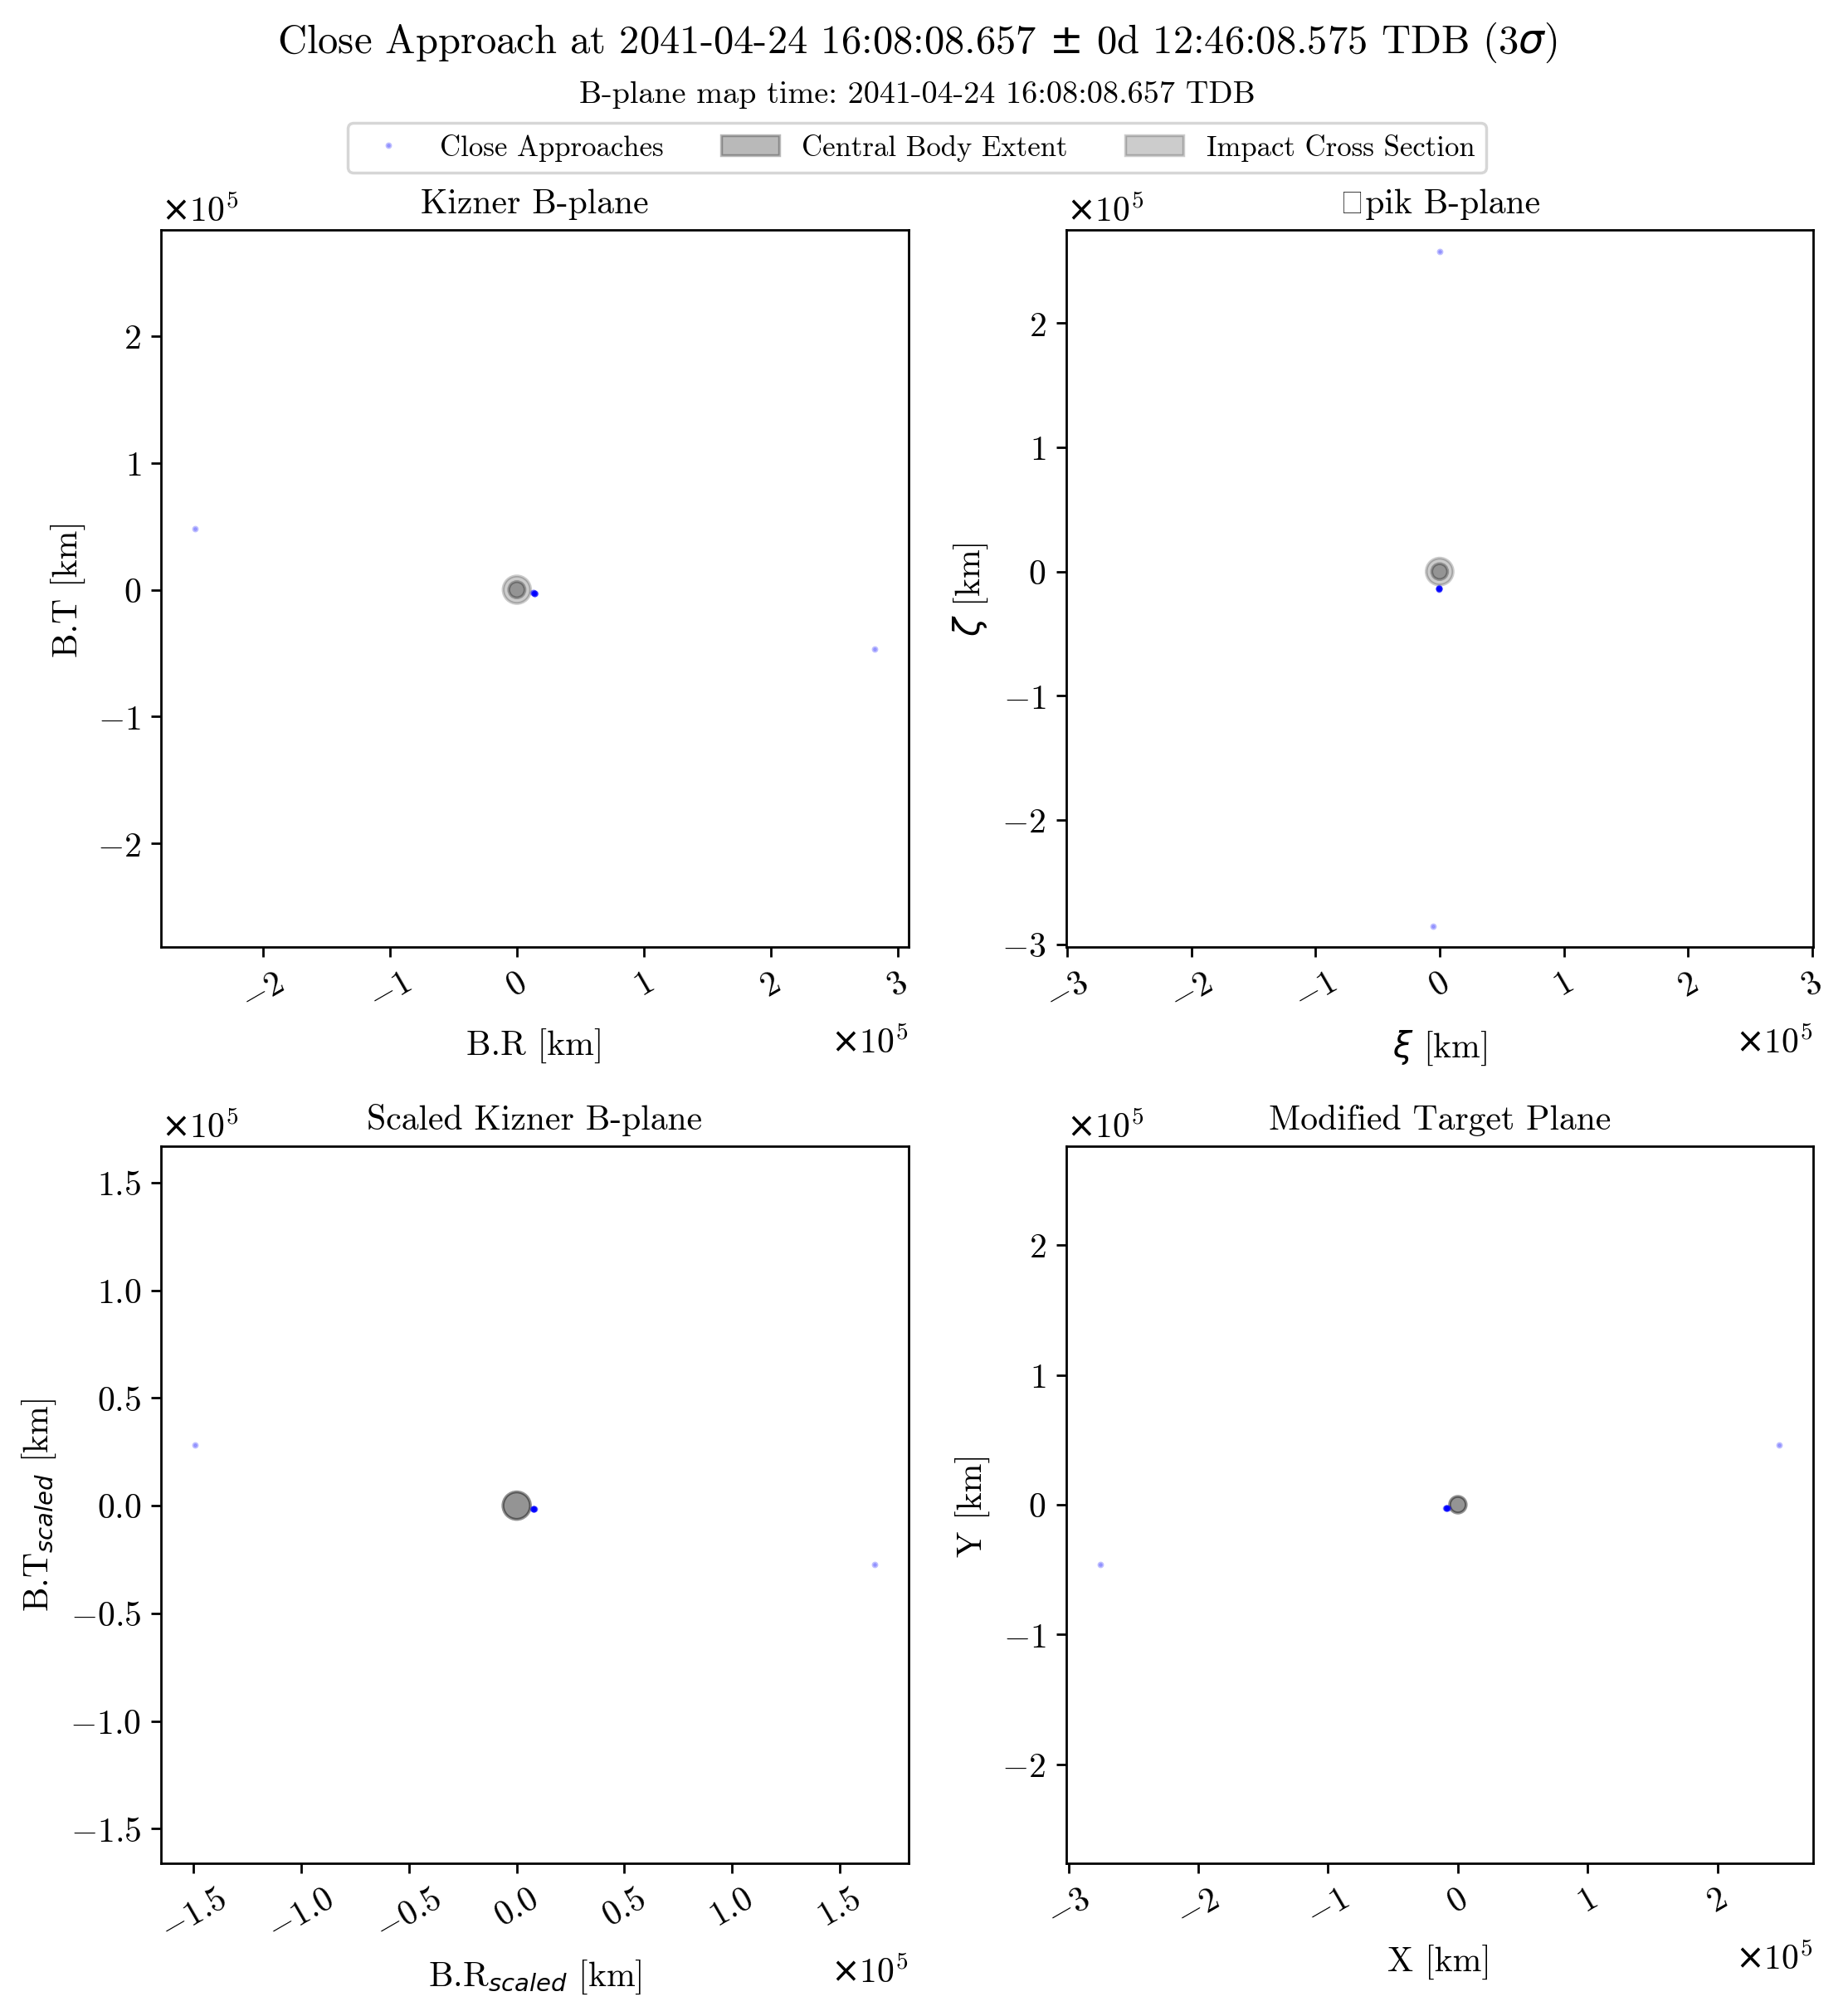

In [48]:
# ============================================================
# Earth intersection check at April 24, 2041
# ============================================================
# Get Earth's heliocentric ecliptic J2000 state from DE440
earth_state = np.array(prop_sim.get_spiceBody_state(t_impact_mjd, 'Earth'))


# --- UT 1-σ uncertainty in the direction toward Earth ---
r_unit   = -rel_pos_AU[0] / np.linalg.norm(rel_pos_AU[0])  # unit vector toward Earth
sigma_r  = np.sqrt(r_unit @ cov_final_cart[:3, :3] @ r_unit) * AU_km
ratio    = distances_km[0] / sigma_r

print()
print(f"  UT 1-σ uncertainty along Earth direction: {sigma_r:>12,.0f} km")
print(f"  Nominal distance / 1-σ = {ratio:.4f}")
if ratio < 1:
    print(f"  → Earth is within the 1-σ ellipsoid!  Impact possible.")
elif ratio < 3:
    print(f"  → Earth is within the 3-σ ellipsoid.  Impact possible.")
else:
    print(f"  → Earth is within the {ratio:.1f}-σ ellipsoid.")

# ============================================================
# B-plane plot: uncertainty ellipse relative to Earth disk
# ============================================================
ca_ordered = [ca_by_sp[k] for k in range(n_sp) if k in ca_by_sp]

if len(ca_ordered) >= 3:
    print(f"\nPlotting Öpik B-plane for {len(ca_ordered)} sigma-point close approaches ...")
    prop.plot_bplane(
        ca_ordered,
        sigma_points = sigma_pts if len(ca_ordered) == n_sp else None,
        units_km     = True,
        n_std        = 3,
        show_central_body = True,
        print_ellipse_params = True
    )
else:
    print(f"\nOnly {len(ca_ordered)} sigma points have caParams → increase caTol if needed.")

# ============================================================
# If any impacts were found, plot the Earth impact map
# ============================================================
if impact_by_sp:
    impact_list = list(impact_by_sp.values())
    prop.plot_earth_impact(
        impact_list,
        print_ellipse_params = True,
        sigma_points = sigma_pts,
        plot_ellipse = True
    )

# ============================================================
# Confirm close-approach time matches April 24, 2041
# ============================================================
if ca_by_sp:
    ca_times_mjd = np.array([ca_by_sp[k].t for k in ca_by_sp])
    t_ca_mean     = np.mean(ca_times_mjd)
    t_ca_min      = np.min(ca_times_mjd)
    t_ca_max      = np.max(ca_times_mjd)
    print()
    print("─" * 64)
    print(f"  Close-approach time summary (all sigma points):")
    print(f"  Mean : {Time(t_ca_mean, format='mjd', scale='tdb').iso[:19]}")
    print(f"  Range: {Time(t_ca_min,  format='mjd', scale='tdb').iso[:10]} "
          f"to {Time(t_ca_max, format='mjd', scale='tdb').iso[:10]}")
    print(f"  PDC25 predicted: 2041-04-24")
    offset_days = t_ca_mean - t_impact_mjd
    print(f"  UT mean offset from prediction: {offset_days:+.2f} days")

  v_∞ = 8.190 km/s   b_impact = 10784 km (1.693 R⊕)
  UT 3σ ellipse: a=39175909 km  b=5903892 km  θ=81.4°


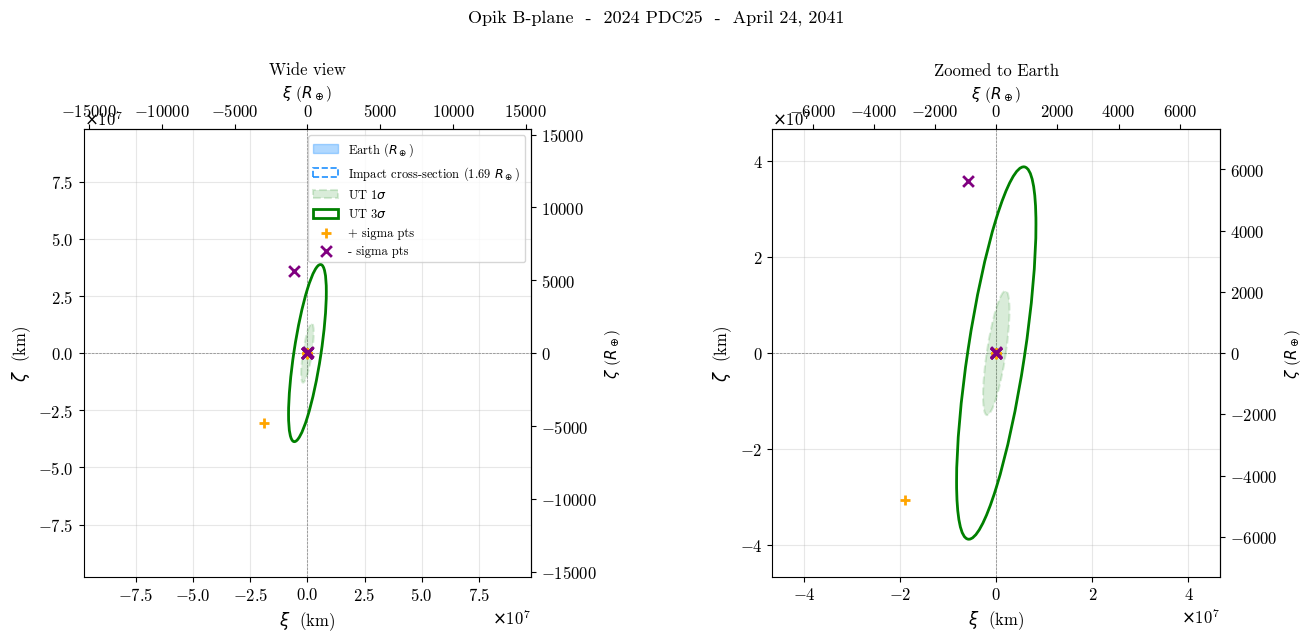

In [45]:

# Öpik B-plane: uncertainty region vs. Earth disk

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse as MEllipse, Circle

# ---- B-plane basis from nominal sigma point -------------------------
z_hat    = np.array([0., 0., 1.])
v_rel    = cart_final[:, 3:] - earth_state[3:]          # (13,3) AU/day
v_hat0   = v_rel[0] / np.linalg.norm(v_rel[0])
e_xi     = np.cross(z_hat, v_hat0); e_xi /= np.linalg.norm(e_xi)
e_zeta   = np.cross(e_xi, v_hat0)

# ---- B-vectors for every sigma point ----------------------------------------
xi_pts   = np.zeros(n_sp)
zeta_pts = np.zeros(n_sp)
B_mag    = np.zeros(n_sp)
for k in range(n_sp):
    v_hat_k     = v_rel[k] / np.linalg.norm(v_rel[k])
    B_vec       = rel_pos_AU[k] - np.dot(rel_pos_AU[k], v_hat_k) * v_hat_k   # AU
    xi_pts[k]   = np.dot(B_vec, e_xi)   * AU_km
    zeta_pts[k] = np.dot(B_vec, e_zeta) * AU_km
    B_mag[k]    = np.linalg.norm(B_vec) * AU_km

# ---- Project UT covariance onto B-plane -------------------------------------
P3   = cov_final_cart[:3, :3]                # (3,3) AU²
H_bp = np.vstack([e_xi, e_zeta]) * AU_km      # (2,3) km/AU
P_bp = H_bp @ P3 @ H_bp.T                     # (2,2) km²
eigvals, eigvecs = np.linalg.eigh(P_bp)
semi_a, semi_b   = np.sqrt(eigvals[::-1])      # km, larger first
ell_angle        = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))

# ---- Gravitational-focusing radius ------------------------------------------
v_inf_km_s  = np.linalg.norm(v_rel[0]) * AU_km / 86400.0
b_impact_km = R_earth_km * np.sqrt(1.0 + (11.186 / v_inf_km_s) ** 2)

print(f"  v_∞ = {v_inf_km_s:.3f} km/s   b_impact = {b_impact_km:.0f} km "
      f"({b_impact_km/R_earth_km:.3f} R⊕)")
print(f"  UT 3σ ellipse: a={3*semi_a:.0f} km  b={3*semi_b:.0f} km  θ={ell_angle:.1f}°")
n_in = int(np.sum(B_mag < b_impact_km))


# ---- Helpers ----------------------------------------------------------------
def km_to_Re(x): return x / R_earth_km
def Re_to_km(x): return x * R_earth_km

def _draw_earth(ax, label=True):
    ax.add_patch(Circle((0,0), R_earth_km, color='dodgerblue', alpha=0.35, zorder=3,
                         label='Earth ($R_\\oplus$)' if label else None))
    ax.add_patch(Circle((0,0), R_earth_km, fill=False, edgecolor='dodgerblue',
                         lw=1.5, zorder=3))
    ax.add_patch(Circle((0,0), b_impact_km, fill=False, edgecolor='dodgerblue',
                         lw=1.2, ls='--', zorder=3,
                         label=f'Impact cross-section ({b_impact_km/R_earth_km:.2f} $R_\\oplus$)'
                               if label else None))

def _draw_ellipses(ax, label=True):
    ax.add_patch(MEllipse(xy=(xi_pts[0], zeta_pts[0]),
                          width=2*semi_a, height=2*semi_b, angle=ell_angle,
                          edgecolor='green', facecolor='green', alpha=0.15,
                          lw=1.5, ls='--', zorder=4,
                          label='UT 1$\\sigma$' if label else None))
    ax.add_patch(MEllipse(xy=(xi_pts[0], zeta_pts[0]),
                          width=6*semi_a, height=6*semi_b, angle=ell_angle,
                          edgecolor='green', facecolor='none',
                          lw=2.0, ls='-', zorder=4,
                          label='UT 3$\\sigma$' if label else None))

# ---- Two-panel figure---------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

for idx, ax in enumerate(axes):
    _draw_earth(ax, label=(idx == 0))
    _draw_ellipses(ax, label=(idx == 0))

    ax.scatter(xi_pts[1:n_dim+1], zeta_pts[1:n_dim+1],
               s=60, color='orange', marker='+', lw=2, zorder=5,
               label='+ sigma pts' if idx == 0 else None)
    ax.scatter(xi_pts[n_dim+1:], zeta_pts[n_dim+1:],
               s=60, color='purple', marker='x', lw=2, zorder=5,
               label='- sigma pts' if idx == 0 else None)


    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xlabel('$\\xi$  (km)', fontsize=12)
    ax.set_ylabel('$\\zeta$  (km)', fontsize=12)

    ax2 = ax.secondary_xaxis('top', functions=(km_to_Re, Re_to_km))
    ax2.set_xlabel('$\\xi$ ($R_\\oplus$)', fontsize=11)
    ay2 = ax.secondary_yaxis('right', functions=(km_to_Re, Re_to_km))
    ay2.set_ylabel('$\\zeta$ ($R_\\oplus$)', fontsize=11)

# Left panel: wide view
pad = max(6*semi_a, 6*semi_b,
          np.abs(xi_pts).max() + semi_a,
          np.abs(zeta_pts).max() + semi_b,
          2.5*R_earth_km) * 1.25
axes[0].set_xlim(-pad, pad); axes[0].set_ylim(-pad, pad)
axes[0].set_title('Wide view', fontsize=12)
axes[0].legend(fontsize=9, loc='upper right')

# Right panel: zoomed to Earth
zoom = max(b_impact_km * 2.0,
           np.abs(xi_pts).max() * 1.3,
           np.abs(zeta_pts).max() * 1.3,
           1.5*semi_b)
axes[1].set_xlim(-zoom, zoom); axes[1].set_ylim(-zoom, zoom)
axes[1].set_title('Zoomed to Earth', fontsize=12)

fig.suptitle('Opik B-plane  -  2024 PDC25  -  April 24, 2041\n',
             fontsize=13)
plt.tight_layout()
plt.show()

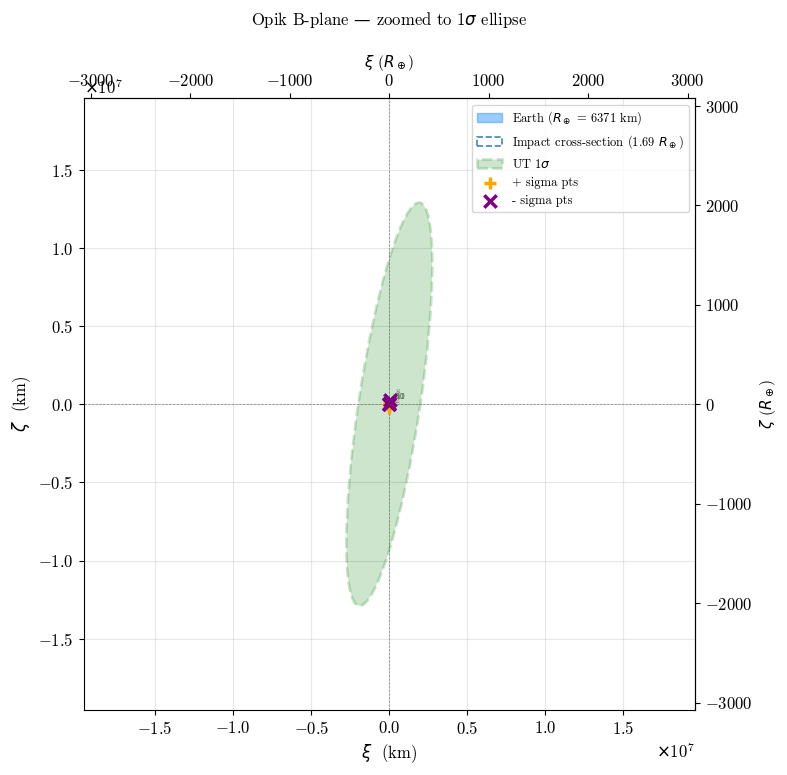

In [44]:

# Zoomed B-plane: 1σ ellipse region — Earth intersection detail

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse as MEllipse, Circle
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(8, 8))

# Earth physical disk
ax.add_patch(Circle((0, 0), R_earth_km,
                    color='dodgerblue', alpha=0.45, zorder=3,
                    label=f'Earth ($R_\\oplus$ = {R_earth_km:.0f} km)'))
ax.add_patch(Circle((0, 0), R_earth_km,
                    fill=False, edgecolor='dodgerblue', lw=1.8, zorder=3))

# Gravitational-focusing ring
ax.add_patch(Circle((0, 0), b_impact_km,
                    fill=False, edgecolor='steelblue', lw=1.2, ls='--', zorder=3,
                    label=f'Impact cross-section ({b_impact_km/R_earth_km:.2f} $R_\\oplus$)'))

# 1σ ellipse
ax.add_patch(MEllipse(xy=(xi_pts[0], zeta_pts[0]),
                      width=2*semi_a, height=2*semi_b, angle=ell_angle,
                      edgecolor='green', facecolor='green', alpha=0.20,
                      lw=2.0, ls='--', zorder=4,
                      label=f'UT 1$\\sigma$ '))

# Sigma points 
inside_1s = B_mag < semi_a 
ax.scatter(xi_pts[1:n_dim+1], zeta_pts[1:n_dim+1],
           s=80, color='orange', marker='+', lw=2.5, zorder=5,
           label='+ sigma pts')
ax.scatter(xi_pts[n_dim+1:], zeta_pts[n_dim+1:],
           s=80, color='purple', marker='x', lw=2.5, zorder=5,
           label='- sigma pts')

# Label each sigma point index
for k in range(n_sp):
    ax.annotate(str(k), (xi_pts[k], zeta_pts[k]),
                fontsize=7, color='gray',
                xytext=(4, 4), textcoords='offset points')

# Zoom: just outside the 1σ ellipse, but at least wide enough to show Earth
pad = max(1.5*semi_a, 1.5*semi_b, 2.5*R_earth_km)
ax.set_xlim(xi_pts[0] - pad, xi_pts[0] + pad)
ax.set_ylim(zeta_pts[0] - pad, zeta_pts[0] + pad)

# Dual axes: km and R⊕
def km_to_Re(x): return x / R_earth_km
def Re_to_km(x): return x * R_earth_km
ax.secondary_xaxis('top', functions=(km_to_Re, Re_to_km)).set_xlabel(
    '$\\xi$ ($R_\\oplus$)', fontsize=11)
ax.secondary_yaxis('right', functions=(km_to_Re, Re_to_km)).set_ylabel(
    '$\\zeta$ ($R_\\oplus$)', fontsize=11)

ax.set_xlabel('$\\xi$  (km)', fontsize=12)
ax.set_ylabel('$\\zeta$  (km)', fontsize=12)
ax.set_title('Opik B-plane — zoomed to 1$\\sigma$ ellipse\n',
             fontsize=12)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()